<a href="https://colab.research.google.com/github/aaronhuang317/Titanic-Passenger-Survival-Prediction-and-Risk-Factor-Analysis/blob/main/Titanic-Passenger-Survival-Prediction-and-Risk-Factor-Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 資料初步載入分析

載入seaborn\pandas



In [38]:
import seaborn as sns
import pandas as pd


先調出在saeborn內建之鐵達尼克號乘客資料並進行初步概觀

In [39]:
titanic_df = sns.load_dataset('titanic')
print("titanic 表格頭部5筆資料")
display(titanic_df.head())
print("titanic 表格尾部5筆資料")
display(titanic_df.tail())
print("表格資料型態及資料缺失情形")
display(titanic_df.info())#缺失值,資料類型(int,float,bool,category,object)
print("表格統計數值")
display(titanic_df.describe())#統計數值(min,max,std,mean,25%/50%)

titanic 表格頭部5筆資料


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


titanic 表格尾部5筆資料


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


表格資料型態及資料缺失情形
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


None

表格統計數值


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [40]:
print("\nMissing values per column:")
display(titanic_df.isnull().sum()) #NaN值設為True並計數


Missing values per column:


,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


筆記:以上分析總結資料總數891筆，缺失項由多到少分別為所在甲板層、年齡、及上船港口

後續須分析數據確定缺失項處理方式

In [41]:
# 將資料儲存為 CSV 檔案
titanic_df.to_csv('titanic.csv', index=False)
print("Titanic 資料已儲存為 'titanic.csv'")

# 再下載下來，或儲存到Mounted Google Drive

Titanic 資料已儲存為 'titanic.csv'


將資料分類調出"類別"與"文字"項目

In [42]:
print("表格資料型態")
display(titanic_df.dtypes)
print("將資料中類別及文字類調出並顯示")
titanic_df_category = titanic_df.select_dtypes(include=['object','category'])
display(titanic_df_category.head())

表格資料型態


,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


將資料中類別及文字類調出並顯示


,sex,embarked,class,who,deck,embark_town,alive
0,male,S,Third,man,NaN,Southampton,no
1,female,C,First,woman,C,Cherbourg,yes
2,female,S,Third,woman,NaN,Southampton,yes
3,female,S,First,woman,C,Southampton,yes
4,male,S,Third,man,NaN,Southampton,no


# 缺失資料分析

In [43]:
missing_deck_by_group = titanic_df.groupby(['class', 'sex'])['deck'].apply(lambda x: x.isnull().sum()).reset_index()
missing_deck_by_group.rename(columns={'deck': 'missing_deck_count'}, inplace=True)

print("按艙等和性別分組的甲板缺失值計數：")
display(missing_deck_by_group)

按艙等和性別分組的甲板缺失值計數：


/tmp/ipykernel_693/3157500756.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  missing_deck_by_group = titanic_df.groupby(['class', 'sex'])['deck'].apply(lambda x: x.isnull().sum()).reset_index()


,class,sex,missing_deck_count
0,First,female,13
1,First,male,28
2,Second,female,66
3,Second,male,102
4,Third,female,138
5,Third,male,341


In [44]:
total_passengers_by_group = titanic_df.groupby(['class', 'sex']).size().reset_index(name='total_passengers')

missing_deck_proportion = pd.merge(
    missing_deck_by_group,
    total_passengers_by_group,
    on=['class', 'sex']
)

missing_deck_proportion['missing_deck_ratio'] = missing_deck_proportion['missing_deck_count'] / missing_deck_proportion['total_passengers']

print("按艙等和性別分組的甲板缺失比例：")
display(missing_deck_proportion)

按艙等和性別分組的甲板缺失比例：


/tmp/ipykernel_693/3199062389.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_passengers_by_group = titanic_df.groupby(['class', 'sex']).size().reset_index(name='total_passengers')


,class,sex,missing_deck_count,total_passengers,missing_deck_ratio
0,First,female,13,94,0.138298
1,First,male,28,122,0.229508
2,Second,female,66,76,0.868421
3,Second,male,102,108,0.944444
4,Third,female,138,144,0.958333
5,Third,male,341,347,0.982709


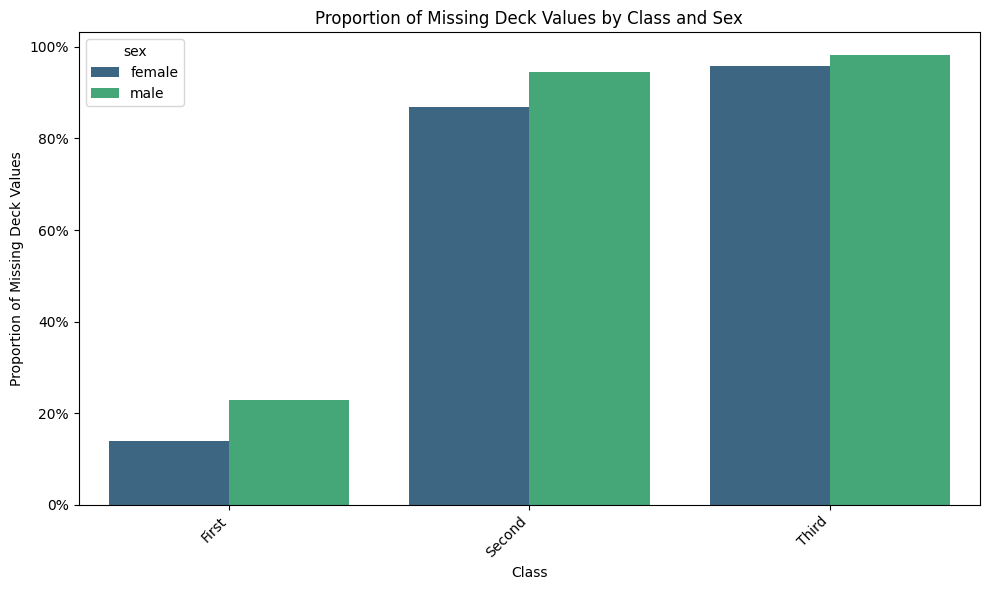

In [45]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns # Ensure seaborn is also imported if not globally available

plt.figure(figsize=(10, 6))
sns.barplot(
    x='class',
    y='missing_deck_ratio',
    hue='sex',
    data=missing_deck_proportion,
    palette='viridis'
)
plt.title('Proportion of Missing Deck Values by Class and Sex')
plt.xlabel('Class')
plt.ylabel('Proportion of Missing Deck Values')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

筆記:分析出頭等艙幾乎沒有損失艙等資料

原因:可能為二三等艙未登記甲板資料

年齡缺失資料分析

猜測與驗證:有成年男性/性別資料為完整資料，判斷是否可以從成年男性推測缺失年齡是否為男性未成年

In [46]:
# 篩選出年齡缺失的資料
missing_age_df = titanic_df[titanic_df['age'].isnull()]

# 從年齡缺失的資料中，找出性別為男性且非成年男性（即為兒童）的乘客
missing_age_male_children = missing_age_df[(missing_age_df['sex'] == 'male') & (missing_age_df['adult_male'] == False)]

# 計算這些乘客的數量
count_missing_age_male_children = len(missing_age_male_children)
total_missing_age = len(missing_age_df)

print(f"總年齡缺失人數: {total_missing_age}")
print(f"年齡缺失的非成年男性人數: {count_missing_age_male_children}")


display(missing_age_male_children.head())

總年齡缺失人數: 177
年齡缺失的非成年男性人數: 0


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone


筆記:未成年男性之際仔年齡皆正確，

年齡資料缺失只剩成年男性/成年女性/未成年女性

In [47]:
# 計算每個性別中年齡缺失的人數
missing_age_by_sex = titanic_df.groupby('sex')['age'].apply(lambda x: x.isnull().sum()).reset_index(name='missing_age_count')

# 計算每個性別的總人數
total_passengers_by_sex = titanic_df.groupby('sex').size().reset_index(name='total_passengers')

# 合併兩個DataFrame並計算年齡缺失比例
missing_age_sex_proportion = pd.merge(
    missing_age_by_sex,
    total_passengers_by_sex,
    on='sex'
)
missing_age_sex_proportion['missing_age_ratio'] = missing_age_sex_proportion['missing_age_count'] / missing_age_sex_proportion['total_passengers']

print("按性別分組的年齡缺失值計數及比例：")
display(missing_age_sex_proportion)

按性別分組的年齡缺失值計數及比例：


,sex,missing_age_count,total_passengers,missing_age_ratio
0,female,53,314,0.168790
1,male,124,577,0.214905


筆記:有124筆資料為成年男性但年齡資料缺失，可稍後判斷是否用平均成年男性年齡補足資料缺失(占總資料21.5%)

In [48]:
# 創建一個新的欄位 'has_age_info'，如果 'age' 不為空則為 True，否則為 False
titanic_df['has_age_info'] = titanic_df['age'].notna()

# 根據 'has_age_info' 分組計算生存率
survival_rate_by_age_info = titanic_df.groupby('has_age_info')['survived'].mean().reset_index()

# 將 True/False 轉換為更具描述性的標籤
survival_rate_by_age_info['age_info_status'] = survival_rate_by_age_info['has_age_info'].map({True: 'Has Age Info', False: 'Missing Age Info'})

print("按年齡資料完整性分組的生存率：")
display(survival_rate_by_age_info)

按年齡資料完整性分組的生存率：


,has_age_info,survived,age_info_status
0,False,0.293785,Missing Age Info
1,True,0.406162,Has Age Info


筆記:年齡缺失與生存率弱相關(10%)，接下來查驗同樣高度與生存率掛勾之艙等分析

In [49]:
# 篩選出年齡缺失的乘客
missing_age_passengers = titanic_df[titanic_df['age'].isnull()]

# 計算年齡缺失乘客中，每個艙等的數量
missing_age_pclass_distribution = missing_age_passengers['pclass'].value_counts().sort_index()

print("年齡缺失乘客中，船艙等級的分佈：")
display(missing_age_pclass_distribution)

年齡缺失乘客中，船艙等級的分佈：


,count
pclass,
1,30
2,11
3,136


結論:大部分年齡未登記為3艙等旅客

# 以視覺化圖表深入分析

筆記:
*  長條圖 `barplot` 用來離散類別的數值資料。圖表的高度代表平均值等統計數據
*  長方圖 `histplot` 畫出與連續數值相關的分布狀況。


將每一類印出其中有哪些以便後續使用統計

In [50]:
display(titanic_df.columns) #此行為印出列(項目分類)
cols = titanic_df_category.columns #定義cols
cols

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone', 'has_age_info'],
      dtype='object')

Index(['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive'], dtype='object')

In [51]:
print("\nUnique values for object and category columns:")
for column in cols:
    print(f"\nColumn '{column}':")#
    display(titanic_df[column].unique())
    print()



Unique values for object and category columns:

Column 'sex':


array(['male', 'female'], dtype=object)



Column 'embarked':


array(['S', 'C', 'Q', nan], dtype=object)



Column 'class':


...

[NaN, 'C', 'E', 'G', 'D', 'A', 'B', 'F']
Categories (7, object): ['A', 'B', 'C', 'D', 'E', 'F', 'G']



Column 'embark_town':


array(['Southampton', 'Cherbourg', 'Queenstown', nan], dtype=object)



Column 'alive':


array(['no', 'yes'], dtype=object)

導入matplotlib以製作視覺化表格

In [52]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick


/tmp/ipykernel_693/241756993.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


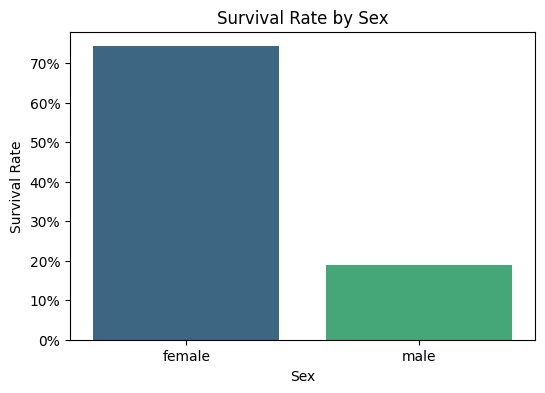

In [53]:
# Calculate survival rate by sex
survival_rate_by_sex = titanic_df.groupby('sex')['survived'].mean().reset_index()


# Create the bar plot
plt.figure(figsize=(6, 4))
sns.barplot(
    x='sex',
    y='survived',
    data=survival_rate_by_sex,
    palette='viridis'
    )
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))#將縱軸換成%數表示

plt.show()

/tmp/ipykernel_693/3132653499.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_rate_by_class = titanic_df.groupby('class')['survived'].mean().reset_index()
/tmp/ipykernel_693/3132653499.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


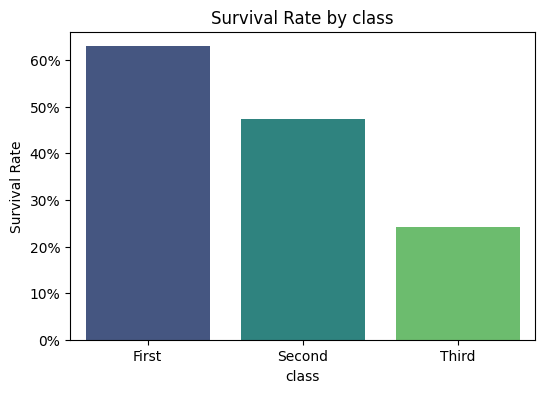

In [54]:
# Calculate survival rate by class
survival_rate_by_class = titanic_df.groupby('class')['survived'].mean().reset_index()

# Create the bar plot
plt.figure(figsize=(6, 4))
sns.barplot(
    x='class',
    y='survived',
    data=survival_rate_by_class,
    palette='viridis' #顏色風格
    )
plt.title('Survival Rate by class')
plt.xlabel('class')
plt.ylabel('Survival Rate')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.show()

男女生存比例有差距先查詢登船性別比

In [55]:
titanic_df['sex'].value_counts()

,count
sex,
male,577
female,314


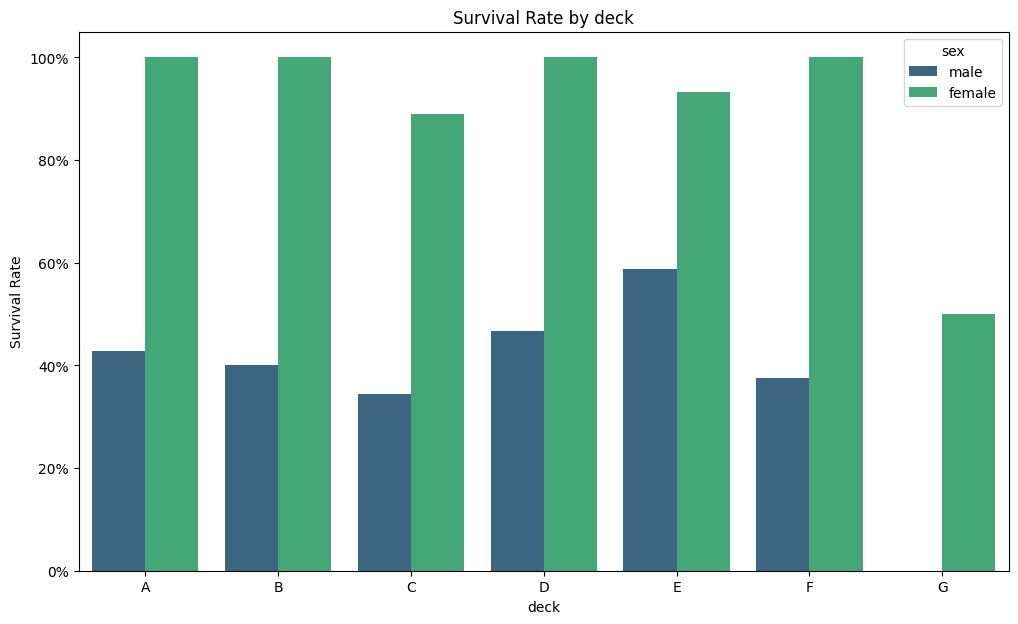

In [56]:
plt.figure(figsize=(12, 7))
sns.barplot(
    x='deck',
    y='survived',
    hue='sex',
    data=titanic_df,
    palette='viridis',
    errorbar=None
    )
plt.title('Survival Rate by deck')
plt.xlabel('deck')
plt.ylabel('Survival Rate')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.show()

In [57]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

first_class_df_with_deck = titanic_df[(titanic_df['pclass']==1) & (titanic_df['deck'].notna())]
first_class_df_with_deck

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,has_age_info
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True,True
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True,True
23,1,1,male,28.0,0,0,35.5000,S,First,man,True,A,Southampton,yes,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False,True
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,True


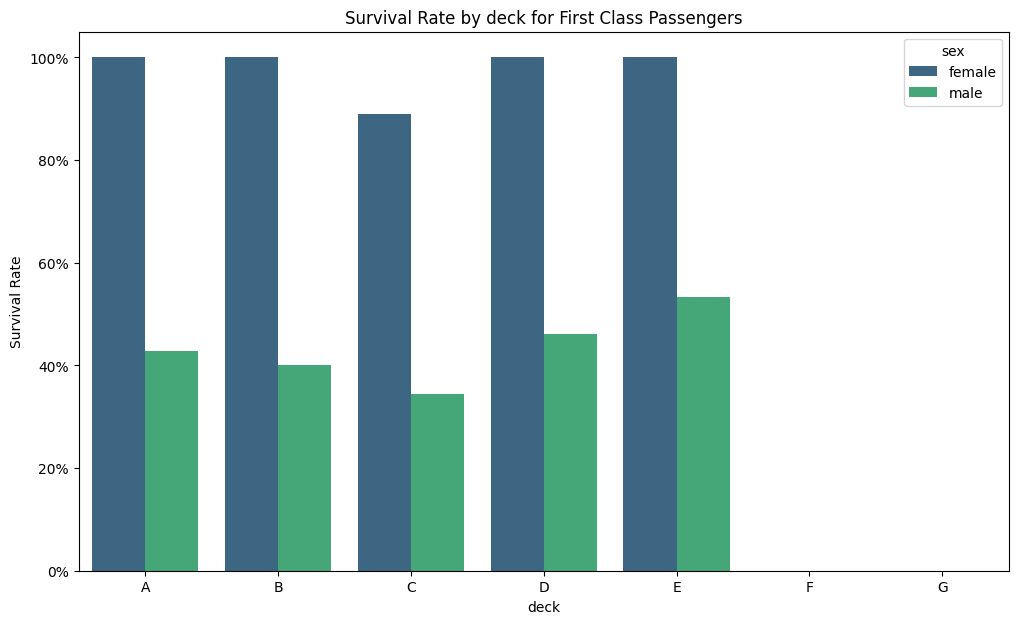

In [58]:

plt.figure(figsize=(12, 7))
sns.barplot(
    x='deck',
    y='survived',
    hue='sex',
    data=first_class_df_with_deck,
    palette='viridis',
    errorbar=None
    )
plt.title('Survival Rate by deck for First Class Passengers')
plt.xlabel('deck')
plt.ylabel('Survival Rate')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.show()

In [59]:
import numpy as np

# Filter for first-class passengers and create a new 'deck_group' column
first_class_df = titanic_df[titanic_df['pclass'] == 1].copy()

first_class_df['deck_group'] = first_class_df['deck'].apply(lambda x: 'A' if x == 'A' else ('C' if x == 'C' else ('Other' if pd.notna(x) else np.nan)))

# Calculate survival rate by the new deck group and sex
survival_rate_by_deck_group = first_class_df.groupby(['deck_group', 'sex'])['survived'].mean().reset_index()

display(survival_rate_by_deck_group)

,deck_group,sex,survived
0,A,female,1.000000
1,A,male,0.428571
2,C,female,0.888889
3,C,male,0.343750
4,Other,female,1.000000
5,Other,male,0.458333


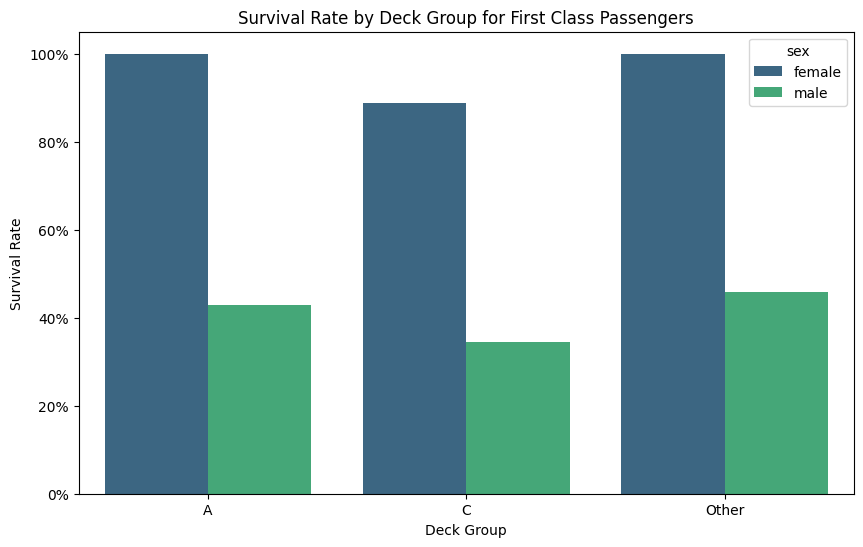

In [60]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x='deck_group',
    y='survived',
    hue='sex',
    data=survival_rate_by_deck_group,
    palette='viridis',
    errorbar=None
)
plt.title('Survival Rate by Deck Group for First Class Passengers')
plt.xlabel('Deck Group')
plt.ylabel('Survival Rate')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.show()

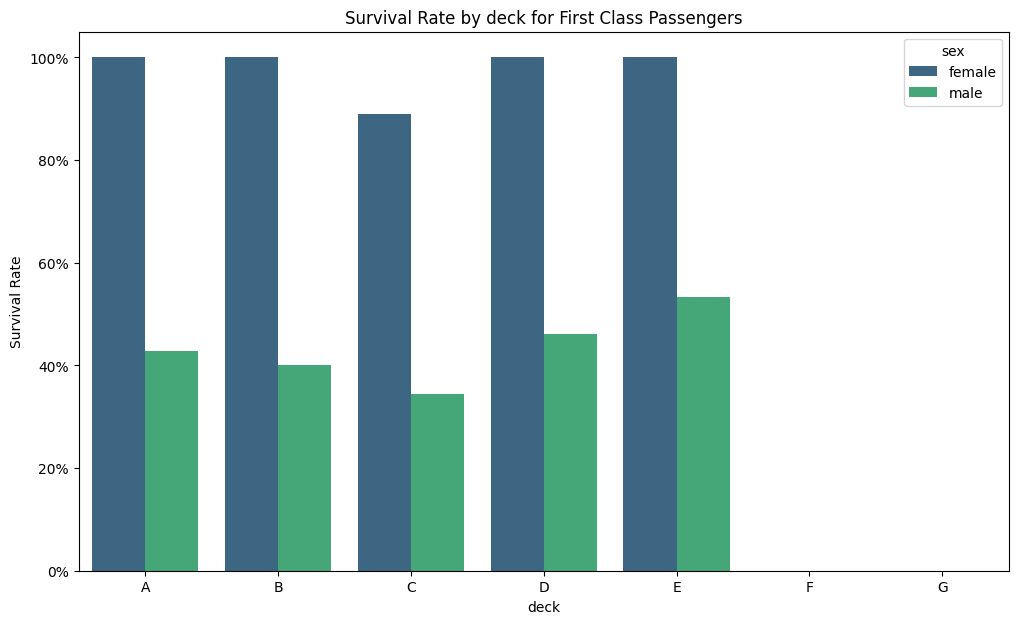

In [61]:
plt.figure(figsize=(12, 7))
sns.barplot(
    x='deck',
    y='survived',
    hue='sex',
    data=first_class_df_with_deck,
    palette='viridis',
    errorbar=None
    )
plt.title('Survival Rate by deck for First Class Passengers')
plt.xlabel('deck')
plt.ylabel('Survival Rate')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.show()

In [62]:
# 頭等艙 且 有甲板資訊的
first_class_df_with_deck = titanic_df[(titanic_df['pclass']==1) & (titanic_df['deck'].notna())]
first_class_df_with_deck

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,has_age_info
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True,True
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True,True
23,1,1,male,28.0,0,0,35.5000,S,First,man,True,A,Southampton,yes,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False,True
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,True


In [63]:
def is_deck_a_g(deck_name):
    if deck_name=='A':
        return "Deck A"
    elif deck_name=='G':
        return "Deck G"
    else:
        return "Other Deck"
first_class_df_with_deck['deck_group'] = first_class_df_with_deck['deck'].apply(is_deck_a_g)
first_class_df_with_deck

/tmp/ipykernel_693/1945409425.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  first_class_df_with_deck['deck_group'] = first_class_df_with_deck['deck'].apply(is_deck_a_g)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,has_age_info,deck_group
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,True,Other Deck
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,True,Other Deck
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True,True,Other Deck
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True,True,Other Deck
23,1,1,male,28.0,0,0,35.5000,S,First,man,True,A,Southampton,yes,True,True,Deck A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False,True,Other Deck
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True,True,Other Deck
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False,True,Other Deck
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,True,Other Deck


不同年齡的生存率

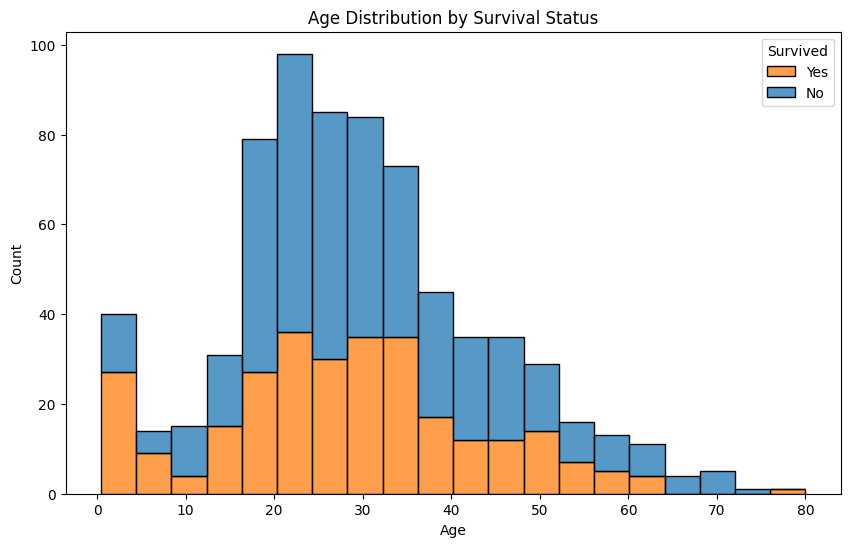

In [64]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=titanic_df,
    x='age', # x軸連續數值
    hue='survived', # y軸連續數值
    # kde=True, # 是否畫曲線
    # palette='coolwarm',
    multiple='stack' # 是否疊起來
)
plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['Yes', 'No'])
plt.show()


不同群體 (男人、女人、小孩) 的生存率

/tmp/ipykernel_693/3945110627.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


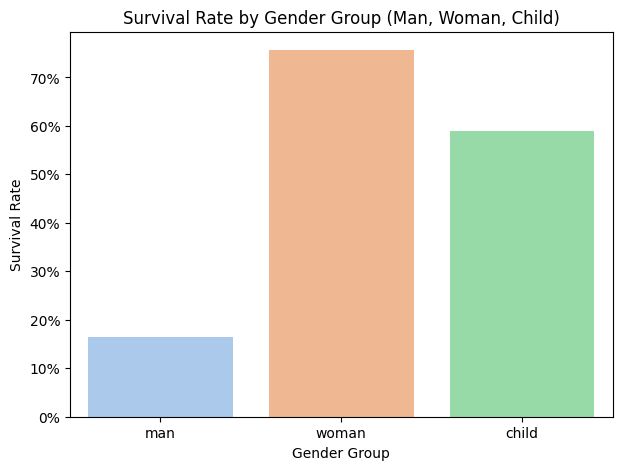

In [65]:
plt.figure(figsize=(7, 5))
sns.barplot(
    x='who', y='survived', data=titanic_df,
    palette='pastel', # 選擇一個不同的調色盤
    errorbar=None
)
plt.title('Survival Rate by Gender Group (Man, Woman, Child)')
plt.xlabel('Gender Group')
plt.ylabel('Survival Rate')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.show()

增加「老人」分類後的不同群體生存率

我們將定義 65 歲及以上的人為「老人」，並在 titanic_df 中創建一個新的欄位 who_extended 來包含這個分類。這將讓我們看到「男人、女人、小孩、老人」四個群體的生存率。

In [66]:
titanic_df[titanic_df['age']>=65]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,has_age_info
33,0,2,male,66.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True,True
54,0,1,male,65.0,0,1,61.9792,C,First,man,True,B,Cherbourg,no,False,True
96,0,1,male,71.0,0,0,34.6542,C,First,man,True,A,Cherbourg,no,True,True
116,0,3,male,70.5,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True,True
280,0,3,male,65.0,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True,True
456,0,1,male,65.0,0,0,26.5500,S,First,man,True,E,Southampton,no,True,True
493,0,1,male,71.0,0,0,49.5042,C,First,man,True,NaN,Cherbourg,no,True,True
630,1,1,male,80.0,0,0,30.0000,S,First,man,True,A,Southampton,yes,True,True
672,0,2,male,70.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True,True
745,0,1,male,70.0,1,1,71.0000,S,First,man,True,B,Southampton,no,False,True


In [67]:
# 複製現有的 'who' 欄位作為基礎
titanic_df['who_extended'] = titanic_df['who']

# 將 65 歲及以上的乘客歸類為 'elderly'
# 注意：這裡會覆蓋掉原先是 'man' 或 'woman' 的老年人
titanic_df.loc[titanic_df['age'] >= 65, 'who_extended'] = 'elderly'

display(titanic_df['who'].value_counts())#算欄位項目出現次數
print(titanic_df['who'].value_counts().sum())

display(titanic_df['who_extended'].value_counts())
print(titanic_df['who_extended'].value_counts().sum())

# 檢查新的 'who_extended' 欄位的唯一值，確認分類正確
print("新的 'who_extended' 分類：", titanic_df['who_extended'].unique())


,count
who,
man,537
woman,271
child,83


891


,count
who_extended,
man,526
woman,271
child,83
elderly,11


891
新的 'who_extended' 分類： ['man' 'woman' 'child' 'elderly']


In [68]:
titanic_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,has_age_info,who_extended
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,True,man
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,True,woman
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,True,woman
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,True,woman
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,True,man


# 機器學習


機器學習
https://scikit-learn.org/stable/

Machine Learning:

          分類(Classification)_預測種類

          回歸(Regression)_預測數字

          分群(Clustering)_在未知標籤的情況下找相似度高的一群


# 資料清洗

In [93]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
import numpy as np

# 複製 DataFrame 以免影響原始數據
df_ml = titanic_df.copy()


#### 甚麼是`fillna()`?

`fillna` 是 Pandas DataFrame 和 Series 物件的一個方法，用於處理資料中的缺失值 (missing values)，也就是 `NaN` (Not a Number) 值。它的主要功能是將這些缺失值替換為指定的值。

**為什麼要處理缺失值？**

如果資料中存在缺失值，模型訓練可能會失敗或產生不準確的結果。

**`fillna` 的主要用法：**

`fillna` 方法可以接受多種參數來指定替換缺失值的方式：

1.  **替換為單一常數值：**
    ```python
    df['column_name'].fillna(value, inplace=True)
    ```
    *   `value`: 你想要替換缺失值的常數 (例如 0, 平均值, 中位數, 眾數等)。
    *   `inplace=True`: 這個參數會直接修改原始 DataFrame，而不是返回一個新的 DataFrame。如果為 `False` (預設值)，則會返回一個新的 DataFrame。

    **範例：**
    *   `df['Age'].fillna(df['Age'].mean(), inplace=True)`: 將 'Age' 欄位中的缺失值替換為該欄位的平均值。
    *   `df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)`: 將 'Embarked' 欄位中的缺失值替換為該欄位的眾數 (最常出現的值)。

2.  **使用前一個有效值填充 (forward fill)：**
    ```python
    df['column_name'].fillna(method='ffill', inplace=True)
    ```
    *   `method='ffill'` (或 `method='pad'`): 會使用前一個非缺失值來填充當前的缺失值。

3.  **使用後一個有效值填充 (backward fill)：**
    ```python
    df['column_name'].fillna(method='bfill', inplace=True)
    ```
    *   `method='bfill'` (或 `method='backfill'`): 會使用後一個非缺失值來填充當前的缺失值。


填補 'age' 的缺失值 (使用中位數)

<Figure size 1000x600 with 0 Axes>

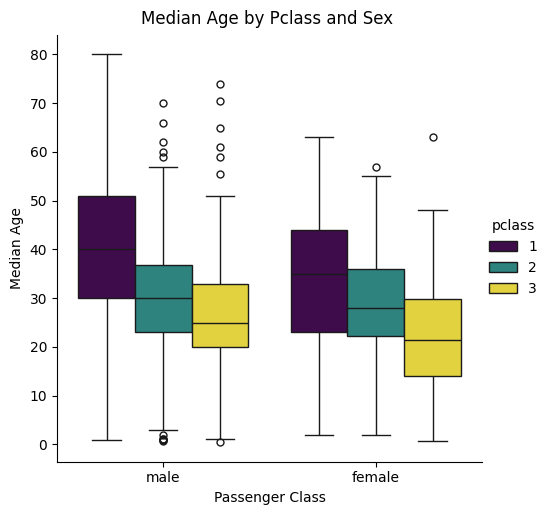

In [94]:
# 繪製根據艙等和性別劃分的年齡中位數
plt.figure(figsize=(10, 6))
sns.catplot(
    x='sex',
    y='age',
    hue='pclass',
    data=df_ml,
    kind='box',
    palette='viridis'
)
plt.suptitle('Median Age by Pclass and Sex', y=1.02) # 調整總標題位置
plt.xlabel('Passenger Class')
plt.ylabel('Median Age')
plt.show()

In [95]:
df_ml.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,has_age_info,who_extended
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,True,man
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,True,woman
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,True,woman
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,True,woman
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,True,man


In [96]:
for g_name, g_data in df_ml.groupby(['sex', 'pclass']):
    group_age_median = g_data['age'].median()
    g_data['age'].fillna(group_age_median, inplace=True)
    df_ml.loc[g_data.index, 'age'] = g_data['age']

/tmp/ipykernel_693/2359042553.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  g_data['age'].fillna(group_age_median, inplace=True)
/tmp/ipykernel_693/2359042553.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [97]:
# 傳統作法: 用分組中位數填補
# for g_name, g_data in df_ml.groupby(['sex', 'pclass']):
#     group_age_median = g_data['age'].median()
#     g_data['age'].fillna(group_age_median, inplace=True)
#     # 須將針對view的修改，實際的更動到原df
#     df_ml.loc[g_data.index, 'age'] = g_data['age']

# 或使用.transform廣播回原df
median_age_by_group = df_ml.groupby(['sex', 'pclass'])['age'].transform('median')
# 使用計算出的中位數來填補 'age' 欄位的缺失值
df_ml['age'].fillna(median_age_by_group, inplace=True)

print("'age' 缺失值已根據 'sex' 和 'pclass' 的分組中位數填補。")
print("確認 'age' 欄位是否還有缺失值：", df_ml['age'].isnull().sum())

'age' 缺失值已根據 'sex' 和 'pclass' 的分組中位數填補。
確認 'age' 欄位是否還有缺失值： 0


/tmp/ipykernel_693/48227357.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ml['age'].fillna(median_age_by_group, inplace=True)


#### `groupby().transform()`

`groupby().transform()` 是 Pandas 中一個強大的功能，它允許你在對 DataFrame 進行分組操作後，將結果返回為一個與原始 DataFrame **具有相同索引和行數**的 Series 或 DataFrame。這對於以下情況特別有用：

*   **填補缺失值**：如你所做，根據組內的統計量（例如中位數、平均值）來填補缺失值。
*   **數據標準化或歸一化**：在每個組內獨立地進行標準化，同時保持原始數據的結構。
*   **計算組內排名**：為每個組內的元素計算其在該組中的排名。

**核心思想**：對每個分組應用一個函數，然後將這個函數的結果廣播回原始 DataFrame 的相應位置，而不是像 `agg()` 那樣返回一個簡化的聚合結果。

這就是為什麼 `df_ml.groupby(['sex', 'pclass'])['age'].transform('median')` 能直接生成一個與 `df_ml['age']` 完全對齊的 Series，以便無縫地用於 `fillna` 操作。

transform(function)

字符串: Pandas 內建的許多聚合函數都可以作為字符串傳入，例如 'sum', 'mean', 'median', 'min', 'max', 'std', 'var', 'count' 等。Pandas 會自動調用對應的方法。
範例: df.groupby('Group')['Value'].transform('mean')
可調用對象 (Callable): 任何接受 Series 或 DataFrame (取決於 transform 應用於 Series 還是整個 DataFrame) 並返回 Series 或 DataFrame 的 Python 函數，包括 lambda 函數。
範例: df.groupby('Group')['Value'].transform(lambda x: (x - x.min()) / (x.max() - x.min())) (組內 Min-Max 歸一化)
範例: df.groupby('Group')['Value'].transform(np.median) (這就是你在程式碼中使用的形式) 。

填補"embarked"資料

In [98]:
mode_embarked = df_ml['embarked'].mode()[0]
df_ml['embarked'].fillna(mode_embarked, inplace=True)
print(f"'embarked' 缺失值已使用眾數 '{mode_embarked}' 填補。")

'embarked' 缺失值已使用眾數 'S' 填補。


/tmp/ipykernel_693/2097119650.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ml['embarked'].fillna(mode_embarked, inplace=True)


丟棄'embark_town'(重複資料)

In [99]:
df_ml.drop('embark_town', axis=1, inplace=True)
print("'embark_town' 欄位已丟棄。")

'embark_town' 欄位已丟棄。


In [ ]:
處理deck

In [100]:
if 'deck' in df_ml.columns:
    df_ml['has_deck'] = df_ml['deck'].notna().astype(int)
    df_ml.drop('deck', axis=1, inplace=True)
    print("'deck'欄位已轉換為'has_deck'特徵並丟棄原始欄位")
else:
    print("'deck'欄位已不存在，無需再次處理。")
df_ml.head()

'deck'欄位已轉換為'has_deck'特徵並丟棄原始欄位


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alive,alone,has_age_info,who_extended,has_deck
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,no,False,True,man,0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,yes,False,True,woman,1
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,yes,True,True,woman,0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,yes,False,True,woman,1
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,no,True,True,man,0


In [101]:
#以前檢查缺失方式
#print("\nMissing values per column:")
#display(df_ml.isnull().sum())


print("\n處理缺失值後，各欄位的缺失值數量：")
display(df_ml.isnull().sum()[df_ml.isnull().sum() > 0])



處理缺失值後，各欄位的缺失值數量：


,0


什麼是 One-Hot Encoding

在機器學習中，模型通常只能處理數值型資料，無法直接理解像 'male'/'female' 或 'S'/'C'/'Q' 這樣的文字類別。如果我們直接將這些類別轉換為單一數字（例如：男性=0，女性=1），模型可能會誤解這些數字之間有大小或順序關係，但實際上並沒有。

One-Hot Encoding 的目的是將類別型特徵轉換為一種向量，使得模型能夠正確理解這些類別而不會引入不必要的順序關係。盡量保持其離散的特性。

例如：

sex 欄位有 'male', 'female' 兩個類別。

'male' 會變成 [1, 0] （假設 'male' 在第二個位置）

'female' 會變成 [0, 1] （假設 'female' 在第一個位置）

embarked 欄位有 'S', 'C', 'Q' 三個類別。

'S' 會變成 [1, 0, 0]

'C' 會變成 [0, 1, 0]

'Q' 會變成 [0, 0, 1]

每個類別都會變成一個新的欄位，該欄位的值只有 0 或 1，表示樣本是否屬於該類別。

In [102]:
# --- 類別特徵編碼與特徵選擇 ---

# 定義用於模型的特徵 (X) 和目標變數 (y)
# 'survived' 是目標變數
# 'pclass', 'sibsp', 'parch', 'fare', 'age' 是數值特徵
# 'sex', 'embarked', 'class', 'who_extended' 是需要 One-Hot 編碼的類別特徵
# 'alone', 'adult_male', 'has_deck' 是布林/二元特徵

features = [
    #'pclass',
    'sibsp', 'parch', 'fare', 'age', 'sex', 'embarked', 'class', 'who_extended', 'alone'
    #,'adult_male', 'has_deck'
    ]
# 選取特徵和目標變數
X = df_ml[features]
y = df_ml['survived']


In [103]:
# 識別類別型欄位
categorical_features = ['sex', 'embarked', 'class', 'who_extended']

# 使用 OneHotEncoder 進行編碼
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded = encoder.fit_transform(X[categorical_features]) # 針對"類別行"處理

# 獲取新的特徵名稱
encoded_feature_names = encoder.get_feature_names_out(categorical_features) # 把每一行名稱列出來

# 將編碼後的特徵轉換為 DataFrame
X_encoded_df = pd.DataFrame(X_encoded, columns=encoded_feature_names, index=X.index)
display(X_encoded_df.head())

,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,class_First,class_Second,class_Third,who_extended_child,who_extended_elderly,who_extended_man,who_extended_woman
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [104]:
# 將數值特徵和編碼後的類別特徵合併
X_numerical = X.drop(columns=categorical_features) # 丟掉 'sex', 'embarked', 'class', 'who_extended'
X_processed = pd.concat([X_numerical, X_encoded_df], axis=1) # 把剩下的欄位 + 新的encoded欄位

print("\n資料預處理完成。現在的特徵集 (X_processed) 的前5行：")
display(X_processed.head())
print(f"\n處理後的特徵維度: {X_processed.shape}")


資料預處理完成。現在的特徵集 (X_processed) 的前5行：


,sibsp,parch,fare,age,alone,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,class_First,class_Second,class_Third,who_extended_child,who_extended_elderly,who_extended_man,who_extended_woman
0,1,0,7.2500,22.0,False,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,1,0,71.2833,38.0,False,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0,0,7.9250,26.0,True,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1,0,53.1000,35.0,False,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0,0,8.0500,35.0,True,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0



處理後的特徵維度: (891, 17)


In [105]:
# 將資料切分為訓練集和測試集 (80% 訓練, 20% 測試)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"訓練集特徵形狀: {X_train.shape}")
print(f"測試集特徵形狀: {X_test.shape}")
print(f"訓練集目標形狀: {y_train.shape}")
print(f"測試集目標形狀: {y_test.shape}")

print("\n資料已成功切分為訓練集和測試集。接下來可以訓練 Random Forest 模型了！")


訓練集特徵形狀: (712, 17)
測試集特徵形狀: (179, 17)
訓練集目標形狀: (712,)
測試集目標形狀: (179,)

資料已成功切分為訓練集和測試集。接下來可以訓練 Random Forest 模型了！


我們將使用 sklearn.ensemble.RandomForestClassifier 來訓練模型。Random Forest 是一種集成學習方法，它通過構建多個決策樹並結合它們的預測來提高準確性和減少過擬合。

這裡我們會設定一些基本參數：

n_estimators: 決策樹的數量。數量越多，模型性能通常越好，但計算成本也越高。

random_state: 隨機種子，用於確保每次運行的結果都是可重現的。

class_weight: 可以處理類別不平衡問題，如果「生存」和「死亡」的樣本數量差異很大，這個參數會有幫助。這裡先使用預設值。

In [106]:
# 初始化 Random Forest 分類器
# n_estimators: 樹的數量，可以調整來取的最佳結果
# random_state: 隨機種子，確保結果可重現
rf_model = RandomForestClassifier(n_estimators=2000, random_state=42)

# 訓練模型
rf_model.fit(X_train, y_train)

print("Random Forest 模型訓練完成！")

Random Forest 模型訓練完成！


模型評估 (Model Evaluation)

模型訓練完成後，我們需要評估其在測試集上的性能。常用的評估指標包括：

準確度 (Accuracy)：模型正確預測的樣本比例。

分類報告 (Classification Report)：提供了精確度 (Precision)、召回率 (Recall)、F1 分數 (F1-score) 和支援度 (Support) 等詳細指標，對於了解模型在每個類別上的表現非常有用。

In [107]:
# 在測試集上進行預測
y_pred = rf_model.predict(X_test)

# 評估模型性能
print("模型準確度 (Accuracy):", accuracy_score(y_test, y_pred))
print("\n分類報告 (Classification Report):\n", classification_report(y_test, y_pred))

模型準確度 (Accuracy): 0.8268156424581006

分類報告 (Classification Report):
               precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.80      0.74      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.83       179



正確率

Accuracy:(TruePositive+TrueNegative)/All

精確度(猜positive且正確)

Precision:TruePositive/(TruePositive+FalsePositive)

召回率(模型中有多少?抓出的比率)

Recall:TruePositive/(TruePositive+FalseNegative)